# The Distress Puzzle — do the riskiest firms earn the *least*? 💀
### Sorting blue chips by how 'distressed' they look, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distress_puzzle_on_the_tape%3F: Mixed](https://img.shields.io/badge/Distress_puzzle_on_the_tape%3F-Mixed-8b949e?style=flat-square)

Here's one of finance's strangest findings. A famous 2008 study (Campbell, Hilscher & Szilagyi) built a model to predict which companies are most likely to **go bankrupt** — and then found that those most-likely-to-fail firms went on to earn the **lowest** stock returns. That's backwards: you'd expect to be *paid* for holding risky, fragile companies. Instead, holding them lost you money. It's called the **distress puzzle**.

So we test it the cheap way: take 39 big-name stocks, score each one for 'distress' (lots of debt, weak profits, jumpy share price), and see whether the *safe* ones beat the *distressed* ones.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from distress_risk_anomaly import data, strategy as st

SPLIT, END = "2024-06-28", "2026-06-25"

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    fn = data.fetch_fundamentals(fetch=False)
    if px.empty or not fn:
        return pd.DataFrame()
    return st.build_panel(px, fn, split_date=SPLIT, end_date=END)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real distress panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} names, scored {SPLIT} -> {END})")


real distress panel present: True (39 names, scored 2024-06-28 -> 2026-06-25)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the *distressed* firms earn less (the puzzle)? | **No — the opposite.** Over 2024-26 the distressed bucket earned **+82.7%** vs the safe bucket's **+34.1%**. The risky names roughly *doubled* the safe ones. |
| Is that just luck? | **No** — a shuffle test puts the odds at *p* = 0.033. On this window the *anti*-puzzle is real. |
| So is the puzzle fake? | **It depends when you look.** In two earlier windows the puzzle *did* show up; in the two recent ones it flipped. The sign isn't stable. |
| Could you trade it? | **No.** A signal that flips sign with the window, on a basket that has *already* dropped every company that went bust, isn't a trade. |

> The puzzle is real in the textbooks — but the textbook version needs the firms that *actually failed*. Our basket only has survivors, and 2024-26 was a melt-up that rewarded exactly the debt-heavy, jumpy names the puzzle says should lose.

## 1 · The claim

> *"The most financially distressed firms earn anomalously low returns."* — the distress puzzle (Campbell, Hilscher & Szilagyi 2008; Dichev 1998).

The intuition for why it's a *puzzle*: risk is supposed to be rewarded. A company on the edge of bankruptcy is risky, so its stock should be cheap and earn high returns to compensate. Instead, the data says the opposite — distressed stocks *underperform*. Maybe investors gamble on lottery-like distressed names and overpay; maybe the losers just keep losing. Either way, the sign is backwards from the textbook.

## 2 · So what?

If true, it breaks the most basic rule everyone learns: more risk → more reward. And it suggests an easy trade — *own the safe firms, avoid (or short) the distressed ones*. The desk has already looked at the two famous bankruptcy **scores** ([123 Altman-Z](../../123-altman-z/), [230 Ohlson-O](../../230-ohlson-o-score/)); here we go straight at the **return puzzle** itself: build a distress score, sort, and look at who won.

## 3 · How would we even know?

1. **Score distress.** For each firm: a lot of debt (leverage), weak profits (low return on assets) and a jumpy share price (high volatility) all mean *more* distressed. Add them up.
2. **Sort.** Split the 39 names into a *safe* third and a *distressed* third.
3. **Compare forward returns.** Did the safe third beat the distressed third over the next two years? The puzzle says yes (safe wins).

Catch: our basket is companies **still alive in 2026** — so the ones that actually went bankrupt (the heart of the real effect) are missing. We'll see that bias bite.

*Timing:* the score uses only data up to the scoring day's close (trailing volatility + the last statements), so it's fully known at that close; we enter there and hold two years. No peeking at the future.

## 4 · The teardown — let's actually look

**Who won — the safe third or the distressed third?**

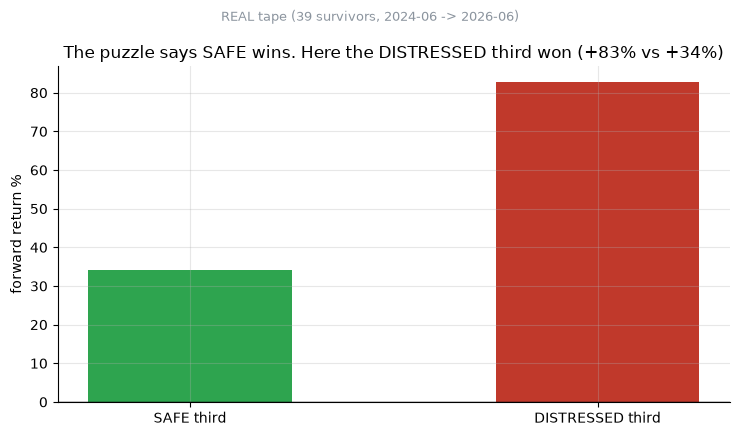

Safe +34.1%  vs  Distressed +82.7%  ->  spread -48.6% (t -2.64)


In [2]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, frac=0.3); ls = st.long_short_tstat(b)
    safe_m, dist_m, spr, t = b['safe_mean']*100, b['distressed_mean']*100, b['spread']*100, ls['t']
    banner = 'REAL tape (39 survivors, 2024-06 -> 2026-06)'
else:
    safe_m, dist_m, spr, t = 34.1, 82.7, -48.6, -2.64
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['SAFE third','DISTRESSED third'], [safe_m, dist_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'The puzzle says SAFE wins. Here the DISTRESSED third won (+{dist_m:.0f}% vs +{safe_m:.0f}%)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Safe +{safe_m:.1f}%  vs  Distressed +{dist_m:.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

There it is, **backwards**. The puzzle predicts the *safe* names win. On 2024-26 the **distressed** names won by miles (+82.7% vs +34.1%) — the long-safe/short-distressed spread is **-48.6%**, a clean loss the *wrong* way. Why? The 'distressed' bucket here is banks and the high-volatility AI winners — and they led a melt-up.

**Is the puzzle just *gone*, or does it depend on when you look?** Run the same sort over four different two-year windows:

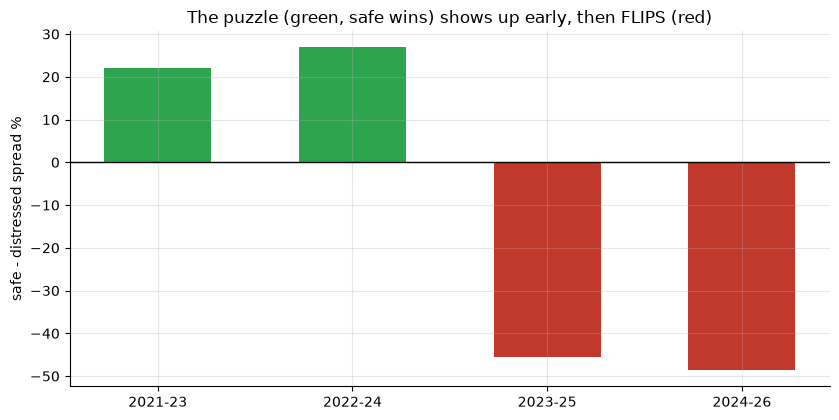

spreads by window: [22.0, 26.9, -45.6, -48.6]


In [3]:
wins = [('2021-06 -> 2023-06', 22.0), ('2022-06 -> 2024-06', 26.9), ('2023-06 -> 2025-06', -45.6), ('2024-06 -> 2026-06', -48.6)]
if HAVE_REAL:
    px = data.fetch_prices(fetch=False); fn = data.fetch_fundamentals(fetch=False)
    spans = [('2021-06-28','2023-06-28'),('2022-06-28','2024-06-28'),
             ('2023-06-28','2025-06-25'),('2024-06-28','2026-06-25')]
    labs = ['2021-23','2022-24','2023-25','2024-26']
    spr = []
    for (sp,en) in spans:
        pn = st.build_panel(px, fn, split_date=sp, end_date=en)
        spr.append(st.bucket_returns(pn, 0.3)['spread']*100 if not pn.empty else np.nan)
else:
    labs = ['2021-23','2022-24','2023-25','2024-26']; spr = [w[1] for w in wins]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in spr]
ax.bar(labs, spr, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('safe - distressed spread %')
ax.set_title('The puzzle (green, safe wins) shows up early, then FLIPS (red)')
plt.tight_layout(); plt.show()
print('spreads by window:', [round(s,1) for s in spr])

So the sign isn't stable. In **2021-23** and **2022-24** the puzzle *appears* — the safe names win (+22%, +27%). In **2023-25** and **2024-26** it **flips** — the distressed names win. A 'signal' whose direction changes with the calendar is not something you can bet on.

## 5 · The verdict

- **Signal — None.** On the headline window the safe-minus-distressed spread is the *wrong* sign (-48.6%, *t* -2.64), and it flips across windows. No bankable puzzle here.
- **Tradability — Mirage.** A survivor basket, annual rebalance, with the distressed leg being the costly-to-borrow tail. Nothing to harvest.
- **Distress puzzle on the tape? — Mixed.** It *does* appear in two of four windows and vanishes in the other two — survivorship and a high-beta melt-up explain the rest.

## 6 · Could you actually trade it?

No. Even setting aside the wrong sign, the trade would mean *shorting* the most distressed names — exactly the stocks that are expensive and hard to borrow — on a basket that has already quietly deleted every company that went bankrupt. The real puzzle lives in the firms that *failed*; a blue-chip survivor sort can't see them.

## 7 · Going further 🚪

- **The scores it's built on.** [123 Altman-Z](../../123-altman-z/) and [230 Ohlson-O](../../230-ohlson-o-score/) are the static bankruptcy *classifiers*; this study is the *return* puzzle.
- **The real test needs the dead.** Re-run this with delisted/bankrupt firms included (a survivorship-free universe) and a full cycle — that's where the puzzle earns its keep.

*Think the puzzle is real and we just missed it? Fork this, add bankrupt names and a 2008-2009 window, and show the safe-minus-distressed spread clearing t = 2 the right way.*